# APTOS 2019 Blindness Detection — Diabetic Retinopathy Severity Classification

## Problem Statement
Diabetic Retinopathy (DR) is a leading cause of preventable blindness. Ophthalmologists currently grade DR
severity manually from retinal fundus photographs, which is slow, requires specialist expertise, and does not
scale well to screening programs in low-resource settings. This project builds a deep learning model that
takes a fundus (retina) image as input and predicts the DR severity grade automatically, so it can be used as
a fast, low-cost triage/screening aid.

## Dataset
**Source:** [APTOS 2019 Blindness Detection](https://www.kaggle.com/competitions/aptos2019-blindness-detection) (Kaggle / Asia Pacific Tele-Ophthalmology Society).
It contains ~3,662 labeled retina images captured under varied conditions (different cameras, lighting,
clinics), which makes it realistic and non-trivial — a good fit for demonstrating a full preprocessing +
CNN transfer-learning pipeline.

**Labels (`diagnosis` column, ordinal severity scale):**
| Code | Class |
|---|---|
| 0 | No DR |
| 1 | Mild |
| 2 | Moderate |
| 3 | Severe |
| 4 | Proliferative DR |

## Notebook Structure
1. Setup & Data Loading
2. Exploratory Data Analysis (EDA)
3. Image Preprocessing
4. Train/Validation Split & Data Pipeline
5. Model Architecture (Transfer Learning)
6. Training
7. Evaluation (incl. Quadratic Weighted Kappa — the official competition metric)
8. Saving the Model for the Streamlit App


## 1. Setup & Data Loading

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/aptos2019-blindness-detection/sample_submission.csv
/kaggle/input/competitions/aptos2019-blindness-detection/train.csv
/kaggle/input/competitions/aptos2019-blindness-detection/test.csv
/kaggle/input/competitions/aptos2019-blindness-detection/train_images/ef476be214d4.png
/kaggle/input/competitions/aptos2019-blindness-detection/train_images/6dcde47060f9.png
/kaggle/input/competitions/aptos2019-blindness-detection/train_images/ec363f48867b.png
/kaggle/input/competitions/aptos2019-blindness-detection/train_images/17f6c7072f61.png
/kaggle/input/competitions/aptos2019-blindness-detection/train_images/b49b2fac2514.png
/kaggle/input/competitions/aptos2019-blindness-detection/train_images/af6166d57f13.png
/kaggle/input/competitions/aptos2019-blindness-detection/train_images/8d13c46e7d75.png
/kaggle/input/competitions/aptos2019-blindness-detection/train_images/c3b15bf9b4bc.png
/kaggle/input/competitions/aptos2019-blindness-detection/train_images/be68322c7223.png
/kagg

In [3]:
import os
import glob
import json
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    cohen_kappa_score,
    confusion_matrix,
    classification_report,
)
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_style("whitegrid")
print("TensorFlow:", tf.__version__)
print("GPUs available:", tf.config.list_physical_devices('GPU'))


TensorFlow: 2.20.0
GPUs available: []


2026-08-26 16:52:10.398731: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [4]:
# ---- Kaggle dataset paths ----
BASE_DIR = "/kaggle/input/competitions/aptos2019-blindness-detection"
TRAIN_IMG_DIR = os.path.join(BASE_DIR, "train_images")
TEST_IMG_DIR = os.path.join(BASE_DIR, "test_images")

train_df = pd.read_csv(os.path.join(BASE_DIR, "train.csv"))
test_df = pd.read_csv(os.path.join(BASE_DIR, "test.csv"))
sample_sub = pd.read_csv(os.path.join(BASE_DIR, "sample_submission.csv"))

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
train_df.head()


Train shape: (3662, 2)
Test shape: (1928, 1)


,id_code,diagnosis
0,000c1434d8d7,2
1,001639a390f0,4
2,0024cdab0c1e,1
3,002c21358ce6,0
4,005b95c28852,0


In [5]:
# Detect actual image file extension (APTOS images are usually .png)
sample_files = os.listdir(TRAIN_IMG_DIR)[:5]
print("Sample files in train_images:", sample_files)
IMG_EXT = os.path.splitext(sample_files[0])[1]  # e.g. '.png'
print("Detected image extension:", IMG_EXT)

def id_to_path(id_code, img_dir=TRAIN_IMG_DIR):
    return os.path.join(img_dir, id_code + IMG_EXT)

train_df["file_path"] = train_df["id_code"].apply(lambda x: id_to_path(x, TRAIN_IMG_DIR))
test_df["file_path"] = test_df["id_code"].apply(lambda x: id_to_path(x, TEST_IMG_DIR))

# Sanity check: do all referenced files actually exist?
missing = train_df[~train_df["file_path"].apply(os.path.exists)]
print(f"Missing training images: {len(missing)}")
print(f"Duplicate id_codes: {train_df['id_code'].duplicated().sum()}")
print(f"Null values:\n{train_df.isnull().sum()}")


Sample files in train_images: ['ef476be214d4.png', '6dcde47060f9.png', 'ec363f48867b.png', '17f6c7072f61.png', 'b49b2fac2514.png']
Detected image extension: .png
Missing training images: 0
Duplicate id_codes: 0
Null values:
id_code      0
diagnosis    0
file_path    0
dtype: int64


## 2. Exploratory Data Analysis (EDA)

We look at (a) class balance — DR datasets are typically imbalanced toward "No DR", which affects our choice
of loss/metrics and motivates class weighting, and (b) what the images actually look like — resolution,
lighting/quality variation, and black-border cropping artifacts from the camera.


/tmp/ipykernel_58/2233806637.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=train_df, x="diagnosis_label", order=order, palette="viridis")


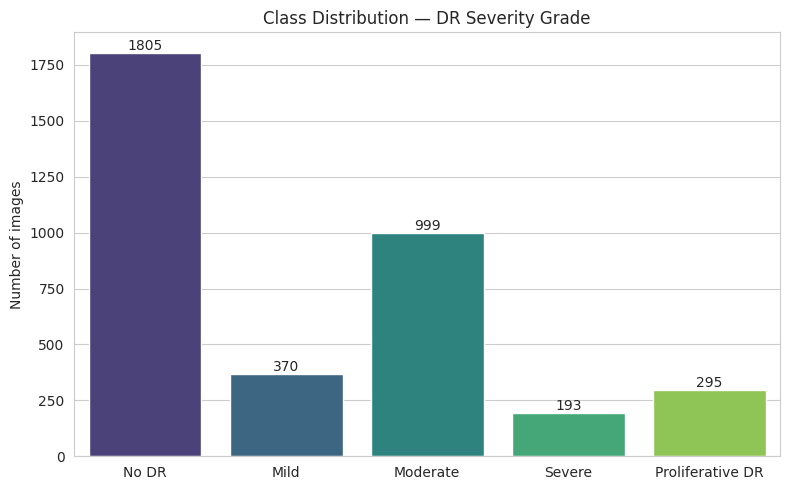

diagnosis_label
No DR               49.3
Moderate            27.3
Mild                10.1
Proliferative DR     8.1
Severe               5.3
Name: proportion, dtype: float64


In [6]:
LABEL_MAP = {0: "No DR", 1: "Mild", 2: "Moderate", 3: "Severe", 4: "Proliferative DR"}
train_df["diagnosis_label"] = train_df["diagnosis"].map(LABEL_MAP)

plt.figure(figsize=(8, 5))
order = list(LABEL_MAP.values())
ax = sns.countplot(data=train_df, x="diagnosis_label", order=order, palette="viridis")
ax.set_title("Class Distribution — DR Severity Grade")
ax.set_xlabel("")
ax.set_ylabel("Number of images")
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")
plt.tight_layout()
plt.show()

print(train_df["diagnosis_label"].value_counts(normalize=True).round(3) * 100)


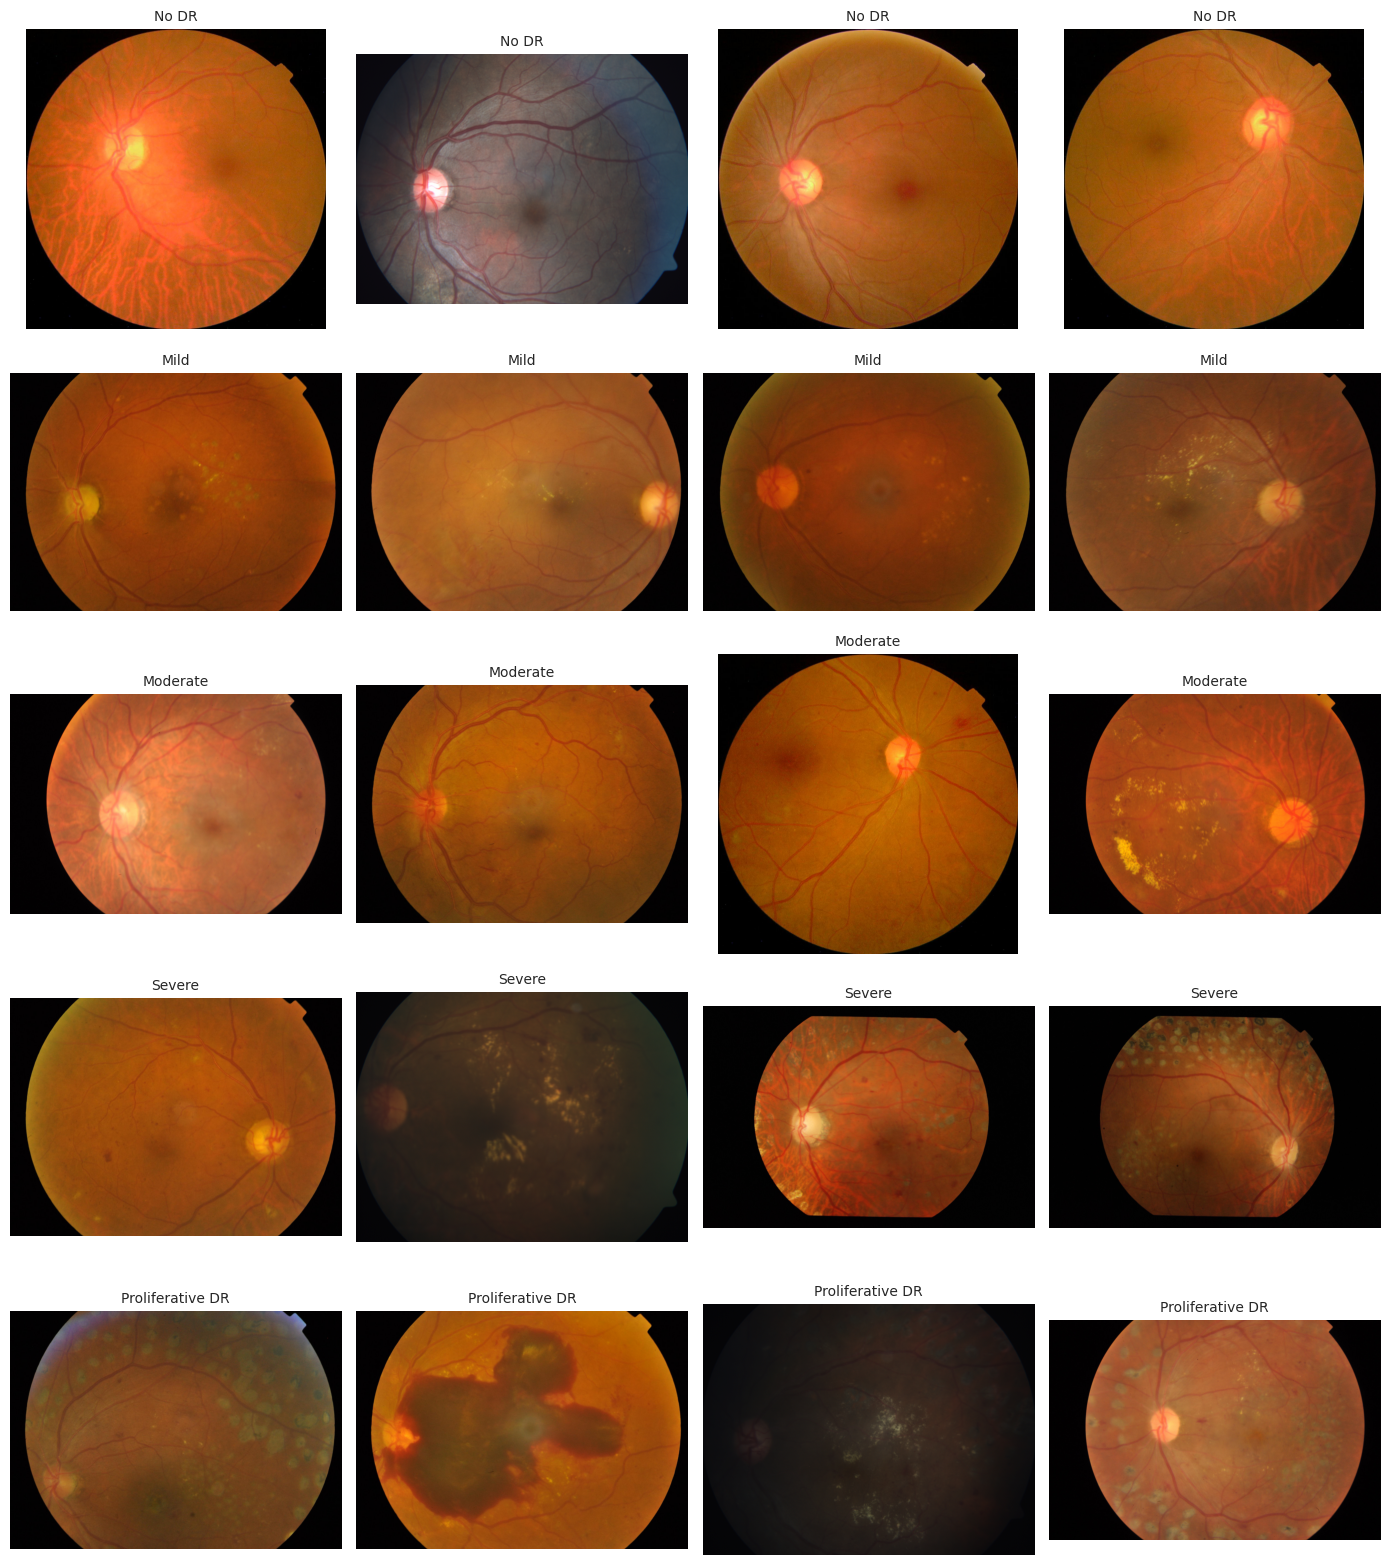

In [7]:
# Visualize a few sample images from each class
fig, axes = plt.subplots(5, 4, figsize=(14, 16))
for row, cls in enumerate(sorted(LABEL_MAP.keys())):
    samples = train_df[train_df["diagnosis"] == cls].sample(4, random_state=SEED)
    for col, (_, r) in enumerate(samples.iterrows()):
        img = cv2.imread(r["file_path"])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[row, col].imshow(img)
        axes[row, col].set_title(f"{LABEL_MAP[cls]}", fontsize=10)
        axes[row, col].axis("off")
plt.tight_layout()
plt.show()


            height        width
count   200.000000   200.000000
mean   1502.675000  1965.285000
std     559.289489   922.585374
min     358.000000   474.000000
25%    1050.000000  1050.000000
50%    1536.000000  2048.000000
75%    1958.000000  2588.000000
max    2848.000000  4288.000000


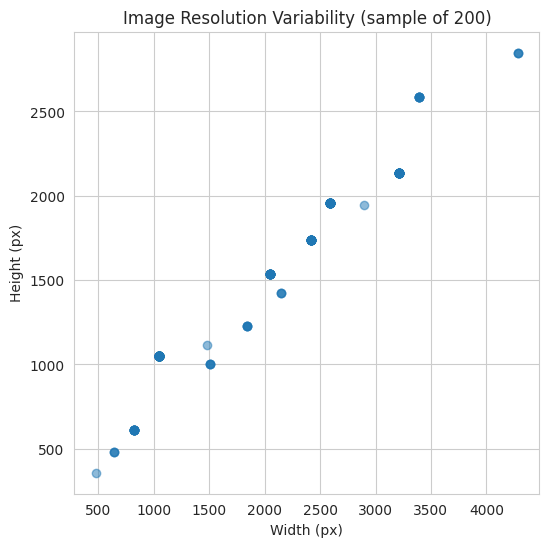

In [8]:
# Check image resolution variability across a random sample
sample_paths = train_df["file_path"].sample(200, random_state=SEED)
shapes = [cv2.imread(p).shape[:2] for p in sample_paths]
shapes_df = pd.DataFrame(shapes, columns=["height", "width"])
print(shapes_df.describe())

plt.figure(figsize=(6, 6))
plt.scatter(shapes_df["width"], shapes_df["height"], alpha=0.5)
plt.xlabel("Width (px)")
plt.ylabel("Height (px)")
plt.title("Image Resolution Variability (sample of 200)")
plt.show()


### 2.1 Extended EDA — Class Balance Visualizations

Beyond the count plot above, a pie chart and a percentage table make the imbalance easier to communicate
in the SRS document / LinkedIn write-up.


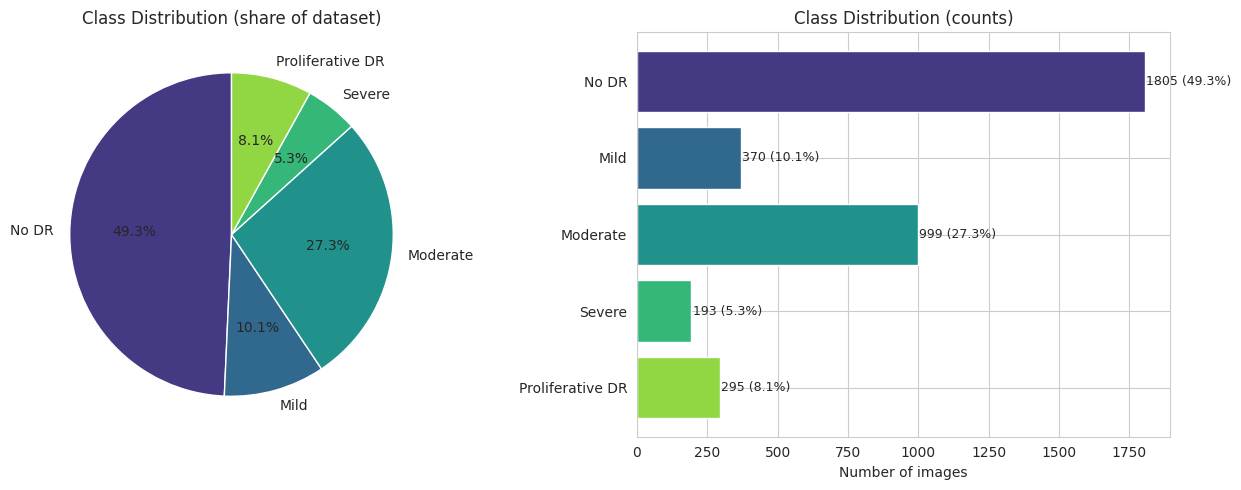

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pie chart
counts = train_df["diagnosis_label"].value_counts().reindex(list(LABEL_MAP.values()))
axes[0].pie(
    counts, labels=counts.index, autopct="%1.1f%%",
    colors=sns.color_palette("viridis", len(counts)), startangle=90,
    wedgeprops={"edgecolor": "white"},
)
axes[0].set_title("Class Distribution (share of dataset)")

# Horizontal bar with counts + percentages
pct = (counts / counts.sum() * 100).round(1)
bars = axes[1].barh(counts.index, counts.values, color=sns.color_palette("viridis", len(counts)))
axes[1].set_xlabel("Number of images")
axes[1].set_title("Class Distribution (counts)")
axes[1].invert_yaxis()
for bar, c, p in zip(bars, counts.values, pct.values):
    axes[1].text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
                 f"{c} ({p}%)", va="center", fontsize=9)

plt.tight_layout()
plt.show()


### 2.2 Image-Level Feature Extraction

To go beyond "what the images look like" into "how do they differ statistically by class", we sample a
capped number of images per class and compute simple engineered features: brightness, contrast, per-channel
color means, saturation, sharpness (blur estimate via Laplacian variance), and aspect ratio. These features
drive the plots in the rest of this section.


In [10]:
N_SAMPLES_PER_CLASS = 150  # cap per class so this stays fast; raise it for a more precise picture

sampled_df = (
    train_df.groupby("diagnosis", group_keys=False)
    .apply(lambda x: x.sample(min(len(x), N_SAMPLES_PER_CLASS), random_state=SEED))
    .reset_index(drop=True)
)

feature_rows = []
for _, row in sampled_df.iterrows():
    img_bgr = cv2.imread(row["file_path"])
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    h, w = gray.shape[:2]

    feature_rows.append({
        "id_code": row["id_code"],
        "diagnosis": row["diagnosis"],
        "height": h,
        "width": w,
        "aspect_ratio": w / h,
        "brightness": gray.mean(),
        "contrast": gray.std(),
        "r_mean": img_rgb[..., 0].mean(),
        "g_mean": img_rgb[..., 1].mean(),
        "b_mean": img_rgb[..., 2].mean(),
        "saturation": hsv[..., 1].mean(),
        "sharpness": cv2.Laplacian(gray, cv2.CV_64F).var(),
    })

feat_df = pd.DataFrame(feature_rows)
feat_df["diagnosis_label"] = feat_df["diagnosis"].map(LABEL_MAP)
feat_df.head()


/tmp/ipykernel_58/2251354569.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), N_SAMPLES_PER_CLASS), random_state=SEED))


,id_code,diagnosis,height,width,aspect_ratio,brightness,contrast,r_mean,g_mean,b_mean,saturation,sharpness,diagnosis_label
0,ef5155990874,0,1050,1050,1.000000,93.564961,50.933630,160.321346,73.660215,21.047376,192.169208,55.530405,No DR
1,0a85a1e8f9e9,0,1958,2588,1.321757,77.070151,34.445766,84.061208,73.892190,75.027730,57.598262,15.111508,No DR
2,6a2642131e4a,0,1050,1050,1.000000,82.518080,45.650537,128.865311,70.587844,22.259025,191.119947,43.328385,No DR
3,8a8a251770cd,0,1050,1050,1.000000,85.858305,45.971529,138.872320,72.438383,15.910099,196.434739,55.482229,No DR
4,ac1667fac512,0,1050,1050,1.000000,73.039551,39.843605,126.306354,59.478572,3.377708,217.694141,42.486910,No DR


### 2.3 Image Quality Metrics by Class (Boxplots & Violin Plots)

/tmp/ipykernel_58/2889524692.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=feat_df, x="diagnosis_label", y="brightness", order=order, ax=axes[0, 0], palette="viridis")
/tmp/ipykernel_58/2889524692.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=feat_df, x="diagnosis_label", y="contrast", order=order, ax=axes[0, 1], palette="viridis")
/tmp/ipykernel_58/2889524692.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=feat_df, x="diagnosis_label", y="saturation", order=order, ax=axes[1, 0], palette="viridis")
/tmp/ipy

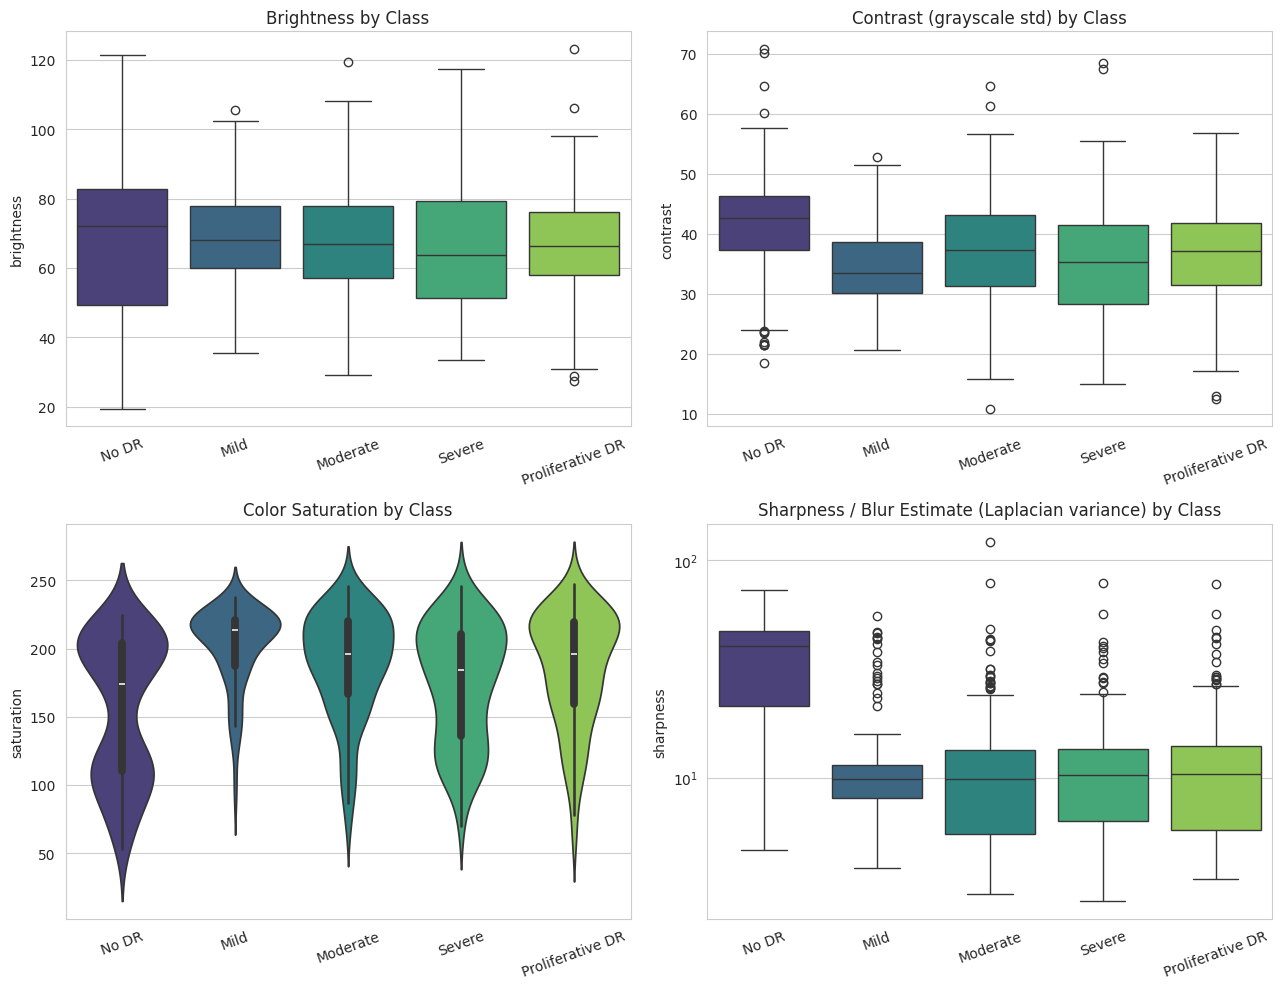

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
order = list(LABEL_MAP.values())

sns.boxplot(data=feat_df, x="diagnosis_label", y="brightness", order=order, ax=axes[0, 0], palette="viridis")
axes[0, 0].set_title("Brightness by Class")
axes[0, 0].set_xlabel("")

sns.boxplot(data=feat_df, x="diagnosis_label", y="contrast", order=order, ax=axes[0, 1], palette="viridis")
axes[0, 1].set_title("Contrast (grayscale std) by Class")
axes[0, 1].set_xlabel("")

sns.violinplot(data=feat_df, x="diagnosis_label", y="saturation", order=order, ax=axes[1, 0], palette="viridis")
axes[1, 0].set_title("Color Saturation by Class")
axes[1, 0].set_xlabel("")

sns.boxplot(data=feat_df, x="diagnosis_label", y="sharpness", order=order, ax=axes[1, 1], palette="viridis")
axes[1, 1].set_title("Sharpness / Blur Estimate (Laplacian variance) by Class")
axes[1, 1].set_xlabel("")
axes[1, 1].set_yscale("log")

for ax in axes.flat:
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


### 2.4 Color Composition

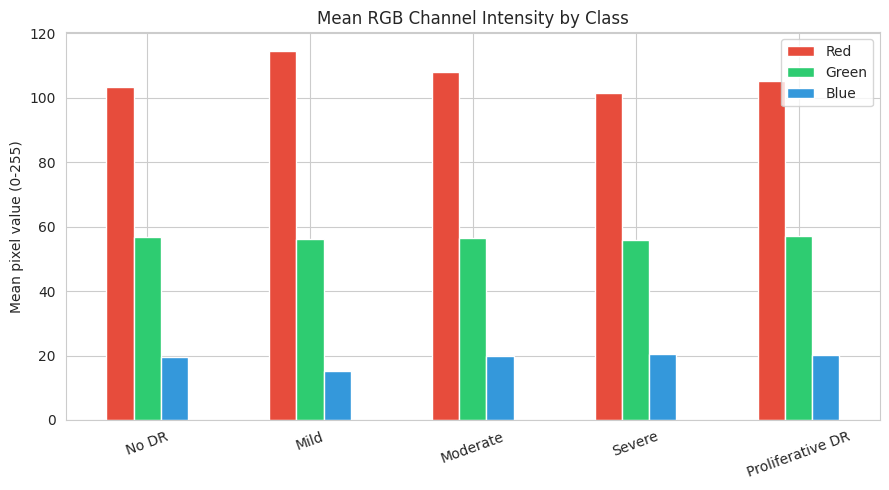

In [12]:
# Grouped bar chart: mean R/G/B channel intensity per class
rgb_by_class = feat_df.groupby("diagnosis_label")[["r_mean", "g_mean", "b_mean"]].mean().reindex(order)

rgb_by_class.plot(kind="bar", figsize=(9, 5), color=["#e74c3c", "#2ecc71", "#3498db"])
plt.title("Mean RGB Channel Intensity by Class")
plt.ylabel("Mean pixel value (0-255)")
plt.xlabel("")
plt.xticks(rotation=20)
plt.legend(["Red", "Green", "Blue"])
plt.tight_layout()
plt.show()


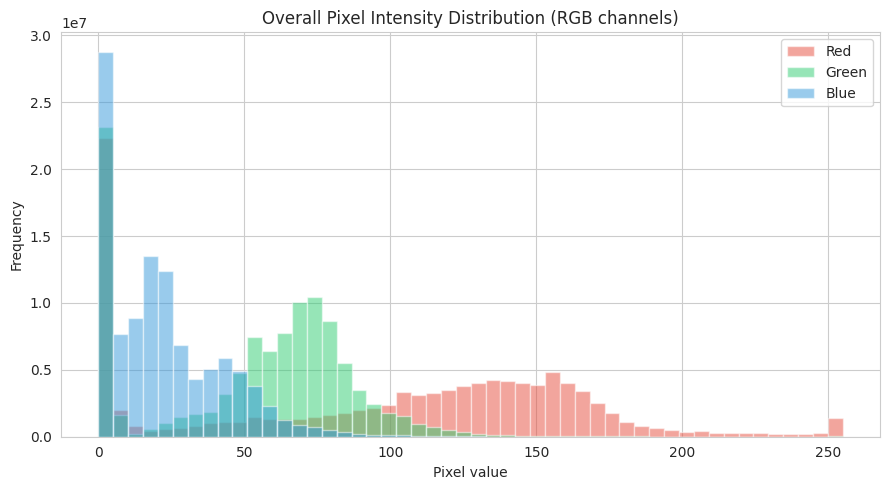

In [13]:
# Overall pixel intensity histogram (RGB) across a small random sample of images
hist_sample = train_df.sample(30, random_state=SEED)
r_vals, g_vals, b_vals = [], [], []
for p in hist_sample["file_path"]:
    img = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)
    r_vals.append(img[..., 0].ravel())
    g_vals.append(img[..., 1].ravel())
    b_vals.append(img[..., 2].ravel())

r_vals, g_vals, b_vals = np.concatenate(r_vals), np.concatenate(g_vals), np.concatenate(b_vals)

plt.figure(figsize=(9, 5))
plt.hist(r_vals, bins=50, alpha=0.5, label="Red", color="#e74c3c")
plt.hist(g_vals, bins=50, alpha=0.5, label="Green", color="#2ecc71")
plt.hist(b_vals, bins=50, alpha=0.5, label="Blue", color="#3498db")
plt.title("Overall Pixel Intensity Distribution (RGB channels)")
plt.xlabel("Pixel value")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()


### 2.5 Image Geometry — Resolution & Aspect Ratio

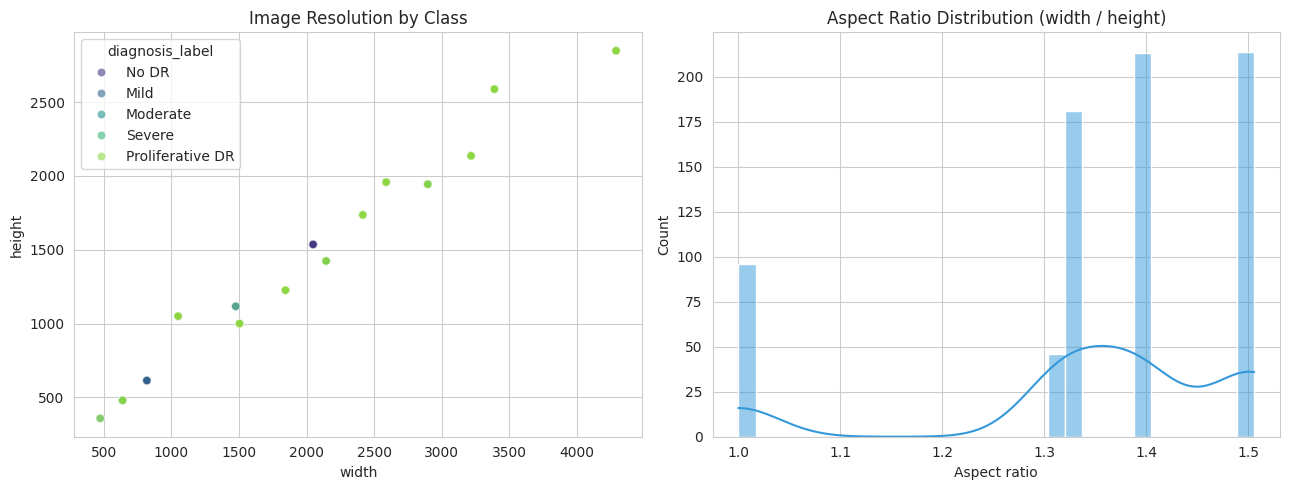

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(data=feat_df, x="width", y="height", hue="diagnosis_label",
                 hue_order=order, palette="viridis", alpha=0.6, ax=axes[0])
axes[0].set_title("Image Resolution by Class")

sns.histplot(feat_df["aspect_ratio"], bins=30, kde=True, ax=axes[1], color="#3498db")
axes[1].set_title("Aspect Ratio Distribution (width / height)")
axes[1].set_xlabel("Aspect ratio")

plt.tight_layout()
plt.show()


### 2.6 Feature Relationships — Correlation Heatmap & Pairplot

Do any of these engineered features actually separate the DR severity classes, or are they just camera/lighting
artifacts unrelated to disease severity? A correlation heatmap and pairplot help sanity-check this before
committing to a modeling approach.


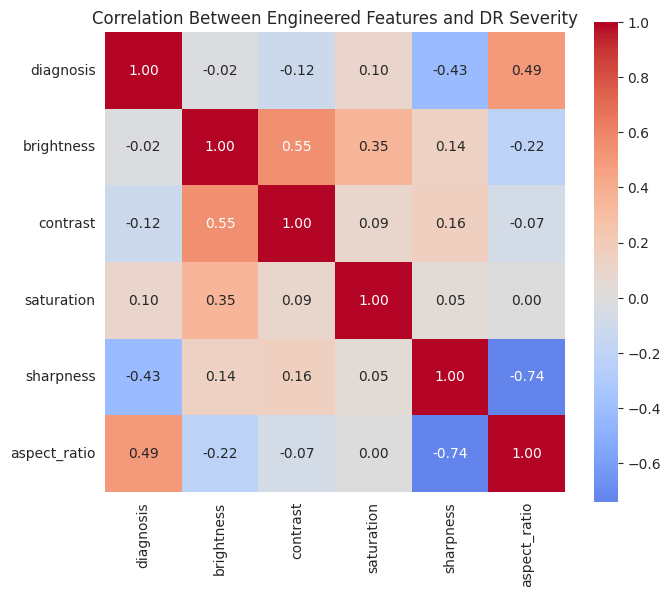

In [15]:
numeric_cols = ["diagnosis", "brightness", "contrast", "saturation", "sharpness", "aspect_ratio"]
corr = feat_df[numeric_cols].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Between Engineered Features and DR Severity")
plt.tight_layout()
plt.show()


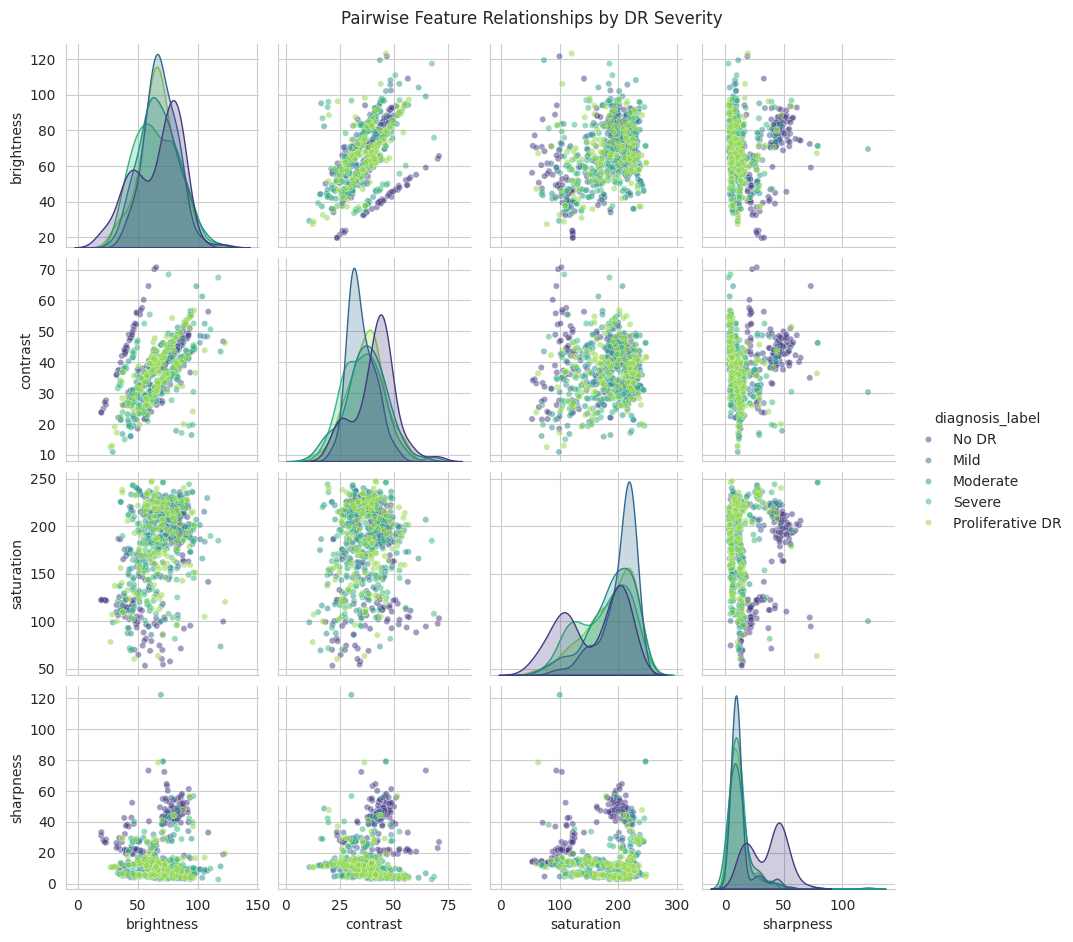

In [16]:
sns.pairplot(
    feat_df,
    vars=["brightness", "contrast", "saturation", "sharpness"],
    hue="diagnosis_label",
    hue_order=order,
    palette="viridis",
    diag_kind="kde",
    plot_kws={"alpha": 0.5, "s": 20},
    height=2.3,
)
plt.suptitle("Pairwise Feature Relationships by DR Severity", y=1.02)
plt.show()


### 2.7 Visual Class Signatures — Average Image per Class

Averaging all (aligned, resized) images within a class can reveal systematic structural differences — e.g.
more diffuse dark regions in higher-severity classes from hemorrhages/exudates — though at this resolution
it mainly shows overall retina shape and illumination pattern.


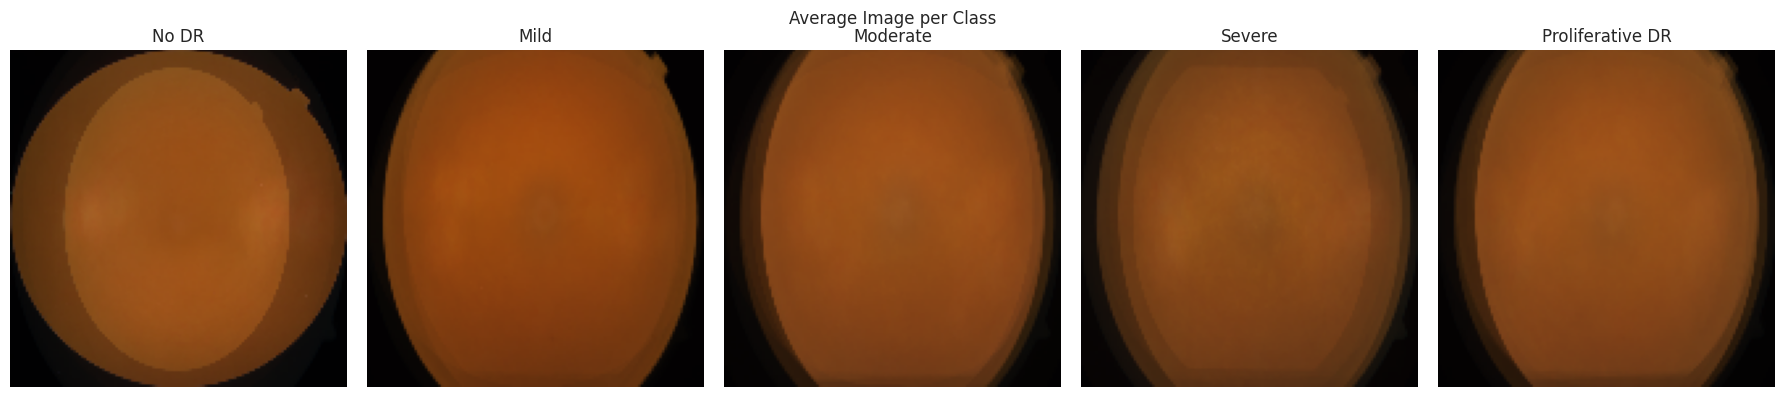

In [17]:
AVG_IMG_SIZE = 128
AVG_SAMPLES_PER_CLASS = 80

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for i, cls in enumerate(sorted(LABEL_MAP.keys())):
    cls_df = train_df[train_df["diagnosis"] == cls].sample(
        min(AVG_SAMPLES_PER_CLASS, (train_df["diagnosis"] == cls).sum()), random_state=SEED
    )
    acc = np.zeros((AVG_IMG_SIZE, AVG_IMG_SIZE, 3), dtype=np.float64)
    for p in cls_df["file_path"]:
        img = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (AVG_IMG_SIZE, AVG_IMG_SIZE)).astype(np.float64)
        acc += img
    avg_img = (acc / len(cls_df)).astype(np.uint8)
    axes[i].imshow(avg_img)
    axes[i].set_title(LABEL_MAP[cls])
    axes[i].axis("off")

plt.suptitle("Average Image per Class")
plt.tight_layout()
plt.show()


### 2.8 Data Quality Checks

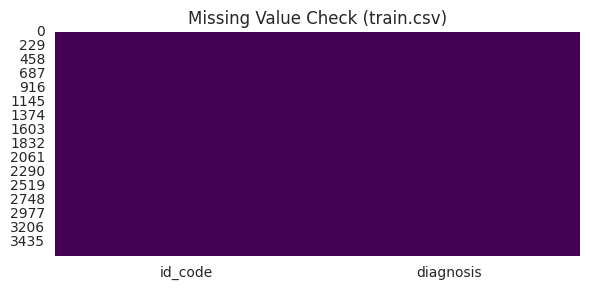

Duplicate id_codes: 0
Rows with missing diagnosis: 0
Files referenced but not found on disk: 0


In [18]:
# Missing-value / completeness heatmap for the metadata table
plt.figure(figsize=(6, 3))
sns.heatmap(train_df[["id_code", "diagnosis"]].isnull(), cbar=False, cmap="viridis")
plt.title("Missing Value Check (train.csv)")
plt.tight_layout()
plt.show()

print(f"Duplicate id_codes: {train_df['id_code'].duplicated().sum()}")
print(f"Rows with missing diagnosis: {train_df['diagnosis'].isnull().sum()}")
print(f"Files referenced but not found on disk: {(~train_df['file_path'].apply(os.path.exists)).sum()}")


## 3. Image Preprocessing

Fundus photographs come with black borders (the camera's circular aperture on a rectangular sensor) and
inconsistent brightness/contrast between clinics and cameras. We apply two well-established preprocessing
steps used across top APTOS solutions:

1. **Crop-from-gray** — remove the black border so the model only sees retina tissue.
2. **Ben Graham-style contrast normalization** — subtract a locally-blurred version of the image to boost
   local contrast (this makes fine features like hemorrhages and microaneurysms far more visible).


In [19]:
IMG_SIZE = 224  # matches EfficientNetB0 input size

def crop_image_from_gray(img, tol=7):
    """Crop away the black border surrounding the retina."""
    gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    mask = gray_img > tol
    if mask.sum() == 0:  # image is (near) fully black — return as-is
        return img
    ys = np.where(mask.any(axis=1))[0]
    xs = np.where(mask.any(axis=0))[0]
    y0, y1 = ys[0], ys[-1]
    x0, x1 = xs[0], xs[-1]
    if x1 - x0 < 10 or y1 - y0 < 10:  # crop degenerate, bail out
        return img
    return img[y0:y1, x0:x1]

def ben_graham_preprocess(img, sigma_x=10):
    """Crop borders, resize, then apply local-contrast enhancement."""
    img = crop_image_from_gray(img)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    blurred = cv2.GaussianBlur(img, (0, 0), sigma_x)
    img = cv2.addWeighted(img, 4, blurred, -4, 128)
    return img

def load_and_preprocess(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return ben_graham_preprocess(img)


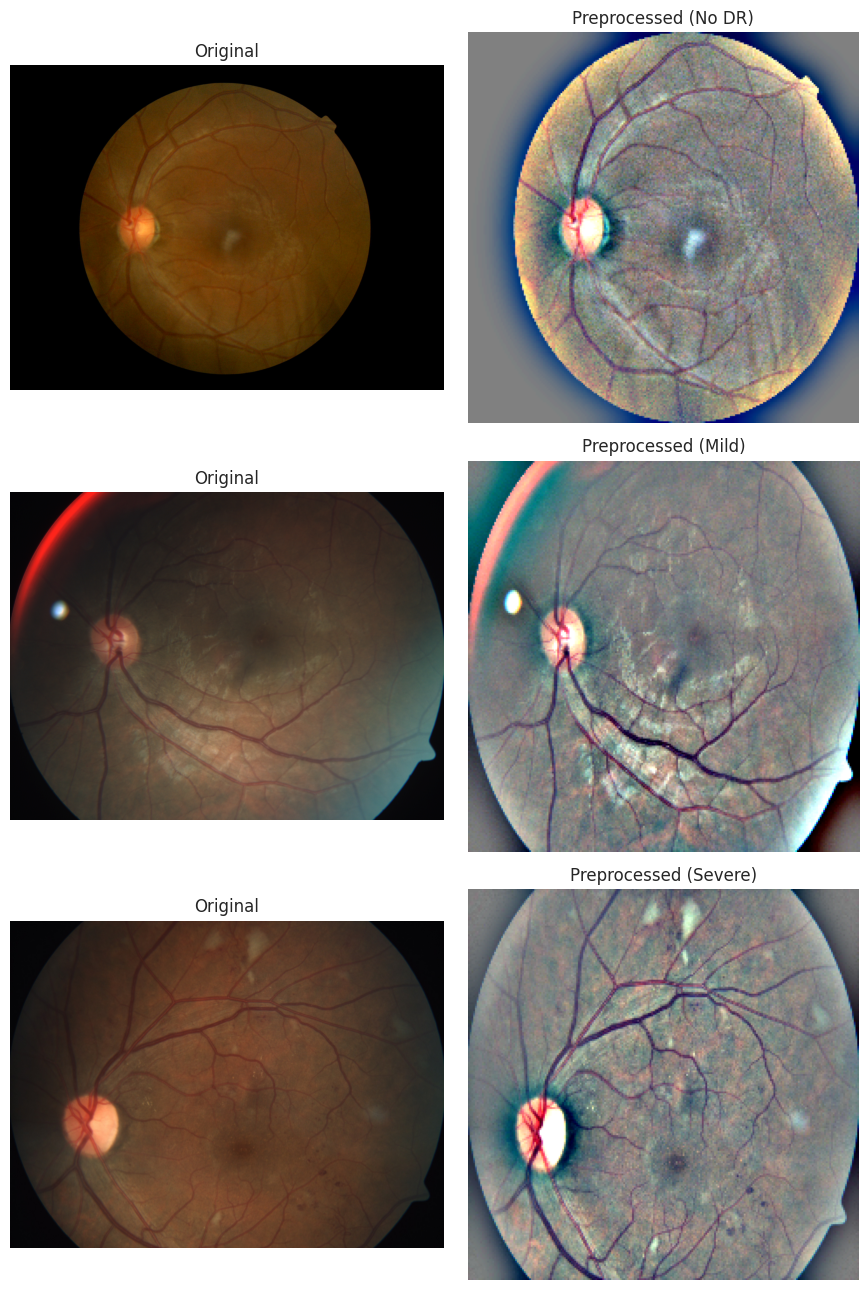

In [20]:
# Visualize the effect of preprocessing: raw vs. cropped+contrast-enhanced
fig, axes = plt.subplots(3, 2, figsize=(9, 13))
samples = train_df.sample(3, random_state=SEED)
for i, (_, r) in enumerate(samples.iterrows()):
    raw = cv2.cvtColor(cv2.imread(r["file_path"]), cv2.COLOR_BGR2RGB)
    processed = ben_graham_preprocess(raw)
    axes[i, 0].imshow(raw); axes[i, 0].set_title("Original"); axes[i, 0].axis("off")
    axes[i, 1].imshow(processed); axes[i, 1].set_title(f"Preprocessed ({LABEL_MAP[r['diagnosis']]})"); axes[i, 1].axis("off")
plt.tight_layout()
plt.show()


## 4. Train/Validation Split & Data Pipeline

We use a **stratified** split so both sets preserve the (imbalanced) class proportions, and build a
`tf.data.Dataset` pipeline that loads + preprocesses images on the fly and applies light augmentation
(flips, rotation, brightness/contrast jitter) to the training set only.


In [22]:
train_data, val_data = train_test_split(
    train_df,
    test_size=0.2,
    stratify=train_df["diagnosis"],
    random_state=SEED,
)
print("Train size:", len(train_data), " Val size:", len(val_data))
print(train_data["diagnosis"].value_counts(normalize=True).sort_index())
print(val_data["diagnosis"].value_counts(normalize=True).sort_index())

NUM_CLASSES = 5
BATCH_SIZE = 32


Train size: 2929  Val size: 733
diagnosis
0    0.493001
1    0.101058
2    0.272789
3    0.052578
4    0.080574
Name: proportion, dtype: float64
diagnosis
0    0.492497
1    0.100955
2    0.272851
3    0.053206
4    0.080491
Name: proportion, dtype: float64


In [23]:
def _load_image_np(path, label):
    path = path.numpy().decode("utf-8")
    img = load_and_preprocess(path)
    img = img.astype(np.float32) / 255.0
    return img, label

def load_image_tf(path, label):
    img, label = tf.py_function(_load_image_np, [path, label], [tf.float32, tf.int32])
    img.set_shape([IMG_SIZE, IMG_SIZE, 3])
    label.set_shape([])
    label = tf.one_hot(label, NUM_CLASSES)
    return img, label

def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, max_delta=0.1)
    img = tf.image.random_contrast(img, lower=0.9, upper=1.1)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, label

def make_dataset(df, training=True):
    paths = df["file_path"].values
    labels = df["diagnosis"].values.astype("int32")
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(len(df), seed=SEED)
    ds = ds.map(load_image_tf, num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_data, training=True)
val_ds = make_dataset(val_data, training=False)

# Class weights to counter the imbalance (esp. rare "Severe" class)
class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_data["diagnosis"]),
    y=train_data["diagnosis"],
)
class_weights = dict(enumerate(class_weights_arr))
print("Class weights:", class_weights)


Class weights: {0: np.float64(0.4056786703601108), 1: np.float64(1.979054054054054), 2: np.float64(0.7331664580725907), 3: np.float64(3.803896103896104), 4: np.float64(2.4822033898305085)}


## 5. Model Architecture — Transfer Learning (EfficientNetB0)

We use **EfficientNetB0** pretrained on ImageNet as a feature extractor, with a custom classification head.
Transfer learning is a good fit here because the labeled dataset is relatively small (~3,600 images) for
training a CNN from scratch, while low-level visual features (edges, textures, blood-vessel-like patterns)
transfer well from ImageNet.

We freeze the base initially (fast training of the head), then optionally fine-tune the top layers of the
base at a low learning rate for a few more epochs.


In [24]:
def build_model(fine_tune=False, fine_tune_at=100):
    base_model = EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
    )
    base_model.trainable = fine_tune
    if fine_tune:
        for layer in base_model.layers[:fine_tune_at]:
            layer.trainable = False

    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base_model(inputs, training=fine_tune)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

    model = keras.Model(inputs, outputs)
    return model, base_model

model, base_model = build_model(fine_tune=False)
model.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,184 (16.08 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

## 6. Training

In [25]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
    keras.callbacks.ModelCheckpoint("best_model.keras", monitor="val_loss", save_best_only=True),
]

EPOCHS_HEAD = 10

history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD,
    class_weight=class_weights,
    callbacks=callbacks,
)


Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 336s 4s/step - accuracy: 0.2055 - loss: 1.6550 - val_accuracy: 0.0532 - val_loss: 1.6116 - learning_rate: 0.0010
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 315s 3s/step - accuracy: 0.0953 - loss: 1.6116 - val_accuracy: 0.1010 - val_loss: 1.6155 - learning_rate: 0.0010
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 338s 4s/step - accuracy: 0.0939 - loss: 1.6120 - val_accuracy: 0.1010 - val_loss: 1.6130 - learning_rate: 0.0010
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 311s 3s/step - accuracy: 0.1482 - loss: 1.6094 - val_accuracy: 0.1010 - val_loss: 1.6113 - learning_rate: 5.0000e-04
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 344s 4s/step - accuracy: 0.0946 - loss: 1.6097 - val_accuracy: 0.0805 - val_loss: 1.6111 - learning_rate: 5.0000e-04
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 313s 3s/step - accuracy: 0.0789 - loss: 1.6097 - val_accuracy: 0.0805 - val_loss: 1.6107 - learning_rate: 5.0000e-04
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 324s 4s/step - accuracy: 0.1304 - loss: 1.60

In [26]:
# Fine-tuning stage: unfreeze top layers of the base model at a low LR
base_model.trainable = True
FINE_TUNE_AT = 100
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

EPOCHS_FINE_TUNE = 8

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINE_TUNE,
    class_weight=class_weights,
    callbacks=callbacks,
)


Epoch 1/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 451s 4s/step - accuracy: 0.2475 - loss: 1.7759 - val_accuracy: 0.0805 - val_loss: 1.6158 - learning_rate: 1.0000e-05
Epoch 2/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 430s 5s/step - accuracy: 0.3520 - loss: 1.6114 - val_accuracy: 0.1119 - val_loss: 1.6273 - learning_rate: 1.0000e-05
Epoch 3/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 464s 5s/step - accuracy: 0.3957 - loss: 1.5120 - val_accuracy: 0.4898 - val_loss: 1.4656 - learning_rate: 5.0000e-06
Epoch 4/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 424s 5s/step - accuracy: 0.4090 - loss: 1.4958 - val_accuracy: 0.4502 - val_loss: 1.3595 - learning_rate: 5.0000e-06
Epoch 5/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 441s 5s/step - accuracy: 0.4179 - loss: 1.4942 - val_accuracy: 0.4857 - val_loss: 1.2046 - learning_rate: 5.0000e-06
Epoch 6/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 410s 4s/step - accuracy: 0.4350 - loss: 1.4523 - val_accuracy: 0.4898 - val_loss: 1.1259 - learning_rate: 5.0000e-06
Epoch 7/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 441s 5s/step - accuracy: 0.4322 - loss:

## 7. Evaluation

Accuracy alone is misleading on an imbalanced, ordinal-severity dataset. The official APTOS 2019 competition
metric is the **Quadratic Weighted Kappa (QWK)**, which measures agreement with the true grade while
penalizing predictions that are further away from the true class more heavily than near-misses (e.g.
predicting "Moderate" instead of "Severe" is penalized less than predicting "No DR" instead of "Severe").
We report QWK, a confusion matrix, and a full classification report.


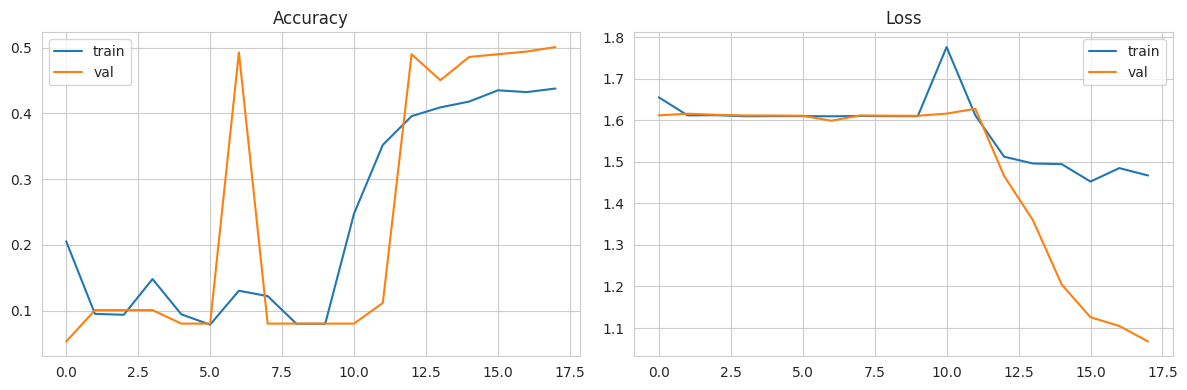

In [27]:
def plot_history(h1, h2=None):
    acc = h1.history["accuracy"]
    val_acc = h1.history["val_accuracy"]
    loss = h1.history["loss"]
    val_loss = h1.history["val_loss"]
    if h2 is not None:
        acc += h2.history["accuracy"]
        val_acc += h2.history["val_accuracy"]
        loss += h2.history["loss"]
        val_loss += h2.history["val_loss"]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(acc, label="train"); axes[0].plot(val_acc, label="val")
    axes[0].set_title("Accuracy"); axes[0].legend()
    axes[1].plot(loss, label="train"); axes[1].plot(val_loss, label="val")
    axes[1].set_title("Loss"); axes[1].legend()
    plt.tight_layout()
    plt.show()

plot_history(history_head, history_fine)


23/23 ━━━━━━━━━━━━━━━━━━━━ 67s 3s/step
Quadratic Weighted Kappa (validation): 0.3764

Classification Report:
                  precision    recall  f1-score   support

           No DR       0.88      0.84      0.86       361
            Mild       0.18      0.68      0.29        74
        Moderate       0.06      0.01      0.02       200
          Severe       0.27      0.10      0.15        39
Proliferative DR       0.11      0.12      0.11        59

        accuracy                           0.50       733
       macro avg       0.30      0.35      0.29       733
    weighted avg       0.49      0.50      0.47       733



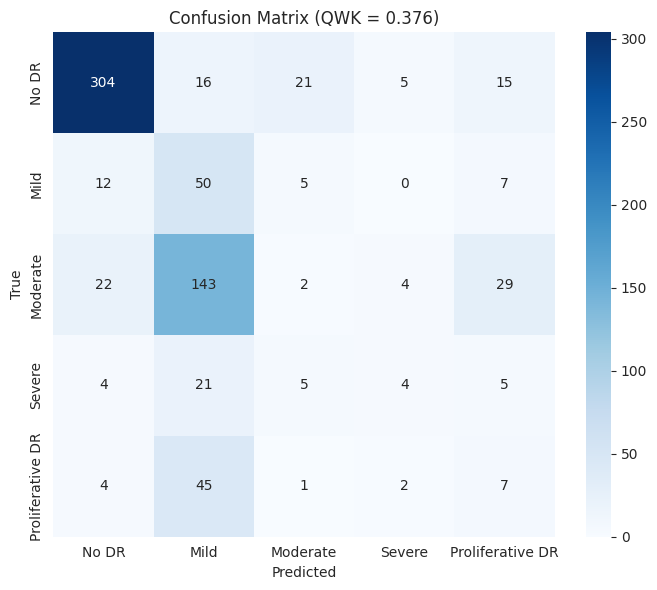

In [28]:
# Predictions on the validation set
val_probs = model.predict(val_ds)
val_preds = np.argmax(val_probs, axis=1)
val_true = val_data["diagnosis"].values

qwk = cohen_kappa_score(val_true, val_preds, weights="quadratic")
print(f"Quadratic Weighted Kappa (validation): {qwk:.4f}")

print("\nClassification Report:")
print(classification_report(val_true, val_preds, target_names=list(LABEL_MAP.values())))

cm = confusion_matrix(val_true, val_preds)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=list(LABEL_MAP.values()), yticklabels=list(LABEL_MAP.values()))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion Matrix (QWK = {qwk:.3f})")
plt.tight_layout()
plt.show()


## 8. Saving the Model for Deployment

We save the trained model and the label mapping so the Streamlit app can load them directly and run
inference on a user-uploaded fundus image.


In [29]:
model.save("dr_model.keras")

with open("label_map.json", "w") as f:
    json.dump(LABEL_MAP, f)

print("Saved dr_model.keras and label_map.json")
print("Copy both files into your Streamlit app's repo before deploying to Streamlit Community Cloud.")


Saved dr_model.keras and label_map.json
Copy both files into your Streamlit app's repo before deploying to Streamlit Community Cloud.


## 9. Links

1. Github: https://github.com/shahmir-raza-works/Deep-Retina.git
2. Streamlit: https://deep-in-retina.streamlit.app/
3. LinkedIn:
4. SRS Doc: 